# Linear Combinations and Span

**This notebook teaches span from scratch — it assumes only that vectors can be scaled and added.**

Given a couple of vectors, which points can you *reach* by scaling and adding them? The complete set of reachable points is called their **span**. Understanding span answers a deep question: do your vectors genuinely point in different directions (covering the whole plane), or are they secretly redundant (covering only a line)? This is the geometric heart of the next notebook on independence and basis.

## Learning objectives

- Form a **linear combination** $a\mathbf{v} + b\mathbf{w}$.
- Describe the **span** of a set of vectors as everything they can reach.
- See that two independent vectors span the whole plane, while dependent ones span only a line.

## Background

A **linear combination** of $\mathbf{v}$ and $\mathbf{w}$ is $a\mathbf{v} + b\mathbf{w}$ for any numbers $a, b$. The **span** is the set of *all* such combinations:

$$\text{span}(\mathbf{v}, \mathbf{w}) = \{\, a\mathbf{v} + b\mathbf{w} \;:\; a, b \in \mathbb{R} \,\}.$$

If $\mathbf{v}$ and $\mathbf{w}$ point in genuinely different directions, their span is the **whole plane**. If one is just a scaled copy of the other, every combination stays on a single **line**.

## This notebook covers

1. A single linear combination.
2. The span of two independent vectors (the whole plane).
3. The span of two dependent vectors (only a line).

**Prerequisites:** `U2-2_Vectors-1_ArrowsAndOps`

**Dataset:** none.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

plt.style.use('dark_background')

import warnings
warnings.filterwarnings('ignore')

# shared display helper (msds520_helpers.py lives at the MSDS 520 course root).
# notebooks sit two folders below it, so '../..' points back to it.
import sys
sys.path.append('../..')
import msds520_helpers as helpers

# --- plotting helper: draw x-y graphs like the usual coordinate plane ---
def center_axes(ax):
    ax.spines['left'].set_position('zero')     # y-axis through x = 0
    ax.spines['bottom'].set_position('zero')   # x-axis through y = 0
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

## 1. A single linear combination

Pick numbers $a$ and $b$, scale each vector, and add. For $\mathbf{v} = \begin{bmatrix}1\\0\end{bmatrix}$ and $\mathbf{w} = \begin{bmatrix}0\\1\end{bmatrix}$, the combination

$$2\mathbf{v} + 3\mathbf{w} = 2\begin{bmatrix}1\\0\end{bmatrix} + 3\begin{bmatrix}0\\1\end{bmatrix} = \begin{bmatrix}2\\3\end{bmatrix}$$

lands at the point $(2, 3)$.

In [2]:
v = np.array([1, 0])
w = np.array([0, 1])

a, b = 2, 3
combination = a * v + b * w
helpers.show(combination, name="2v + 3w")

<IPython.core.display.Math object>

## 2. The span of two independent vectors

If we let $a$ and $b$ range over many values, the combinations $a\mathbf{v} + b\mathbf{w}$ scatter across the plane. When $\mathbf{v}$ and $\mathbf{w}$ point in different directions, those points fill the **entire plane** — their span is everything.

*(The scatter code is just graphics; the point is that the dots cover the plane.)*

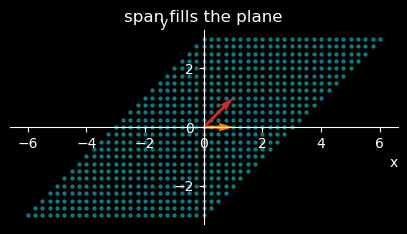

In [3]:
v = np.array([1, 0])
w = np.array([1, 1])   # a different direction from v

# make many combinations a*v + b*w
points_x = []
points_y = []
for a in np.linspace(-3, 3, 25):
    for b in np.linspace(-3, 3, 25):
        p = a * v + b * w
        points_x.append(p[0])
        points_y.append(p[1])

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(points_x, points_y, s=5, color="tab:cyan", alpha=0.5)
ax.quiver(0, 0, v[0], v[1], angles="xy", scale_units="xy", scale=1, color="tab:orange")
ax.quiver(0, 0, w[0], w[1], angles="xy", scale_units="xy", scale=1, color="tab:red")
center_axes(ax)
ax.set_xlabel("x", loc="right")
ax.set_ylabel("y", loc="top", rotation=0)
ax.set_title("span fills the plane")
ax.set_aspect("equal")
plt.show()

## 3. The span of two dependent vectors

Now let $\mathbf{w}$ be just a scaled copy of $\mathbf{v}$. Every combination $a\mathbf{v} + b\mathbf{w}$ is still a multiple of $\mathbf{v}$, so no matter what $a, b$ we choose, we never leave a single **line**. The second vector added nothing new.

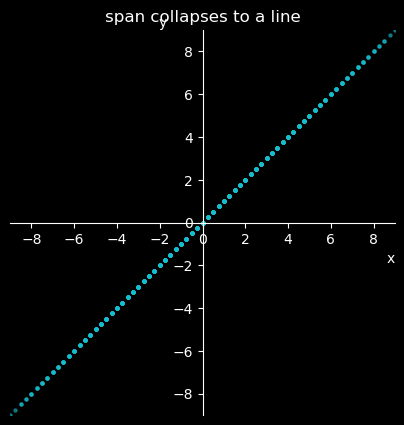

In [4]:
v = np.array([1, 1])
w = np.array([2, 2])   # w = 2*v  -> same direction, redundant

points_x = []
points_y = []
for a in np.linspace(-3, 3, 25):
    for b in np.linspace(-3, 3, 25):
        p = a * v + b * w
        points_x.append(p[0])
        points_y.append(p[1])

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(points_x, points_y, s=5, color="tab:cyan", alpha=0.5)
center_axes(ax)
ax.set_xlabel("x", loc="right")
ax.set_ylabel("y", loc="top", rotation=0)
ax.set_title("span collapses to a line")
ax.set_xlim(-9, 9); ax.set_ylim(-9, 9); ax.set_aspect("equal")
plt.show()

## 4. Summary

- A **linear combination** is $a\mathbf{v} + b\mathbf{w}$; the **span** is *all* such combinations.
- Two vectors in **different directions** span the whole plane.
- If one is a **scaled copy** of the other, the span collapses to a **line** — the second vector is redundant.

Next: naming this redundancy precisely and choosing a good set of directions — **independence and basis** (`U2-2_Vectors-5_IndependenceAndBasis`).